# RQ2: Trigger dei workflow (on: push, on: pull_request, on: schedule...) — capire come questi sistemi AI vengono integrati e testati e in quali step di workflow

##### nb: Sostanzialmente estraendo questi dati e prendendo le top keywords, vogliamo capire QUANDO i workflows vengono triggerati in queste repositories.

In [1]:
import pandas as pd

DATASET_PATH = "C:\\dev\\SE4AI-base\\gigawork\\dataset_with_ids.csv"
BASE_GIGAWORK_PATH = "C:\\dev\\SE4AI-base\\gigawork\\all_workflows"

df = pd.read_csv(DATASET_PATH)

In [2]:
repositories = df.groupby("repository")

# per ogni repository prendiamo tutti i file hash associati allo stesso file hash, se il file è stato eliminato prendiamo l'ultimo.
tmp = df.dropna(subset=["repository", "workflow_global_id"]).copy()

# timestamp per prendere l'ultima modifica effettuata al file
tmp["event_ts"] = pd.to_numeric(tmp["committed_date"], errors="coerce")
tmp["event_ts"] = tmp["event_ts"].fillna(pd.to_numeric(tmp["authored_date"], errors="coerce"))
tmp["file_h"] = tmp["file_hash"].fillna(tmp["previous_file_hash"])

last_file = (
    tmp.sort_values(["repository", "workflow_global_id", "event_ts"])
       .groupby(["repository", "workflow_global_id"], as_index=False)
       .tail(1)
       .reset_index(drop=True)
)
repo_summary = (
    last_file.groupby("repository", as_index=False)
    .agg(
        files=("file_h", lambda s: [x for x in s.dropna().unique()]),
    )
    .reset_index(drop=True)
)

In [7]:
import yaml
from pathlib import Path
from collections import Counter


def get_on_section(workflow_dict):
    """Ritorna il contenuto della chiave `on`, gestendo anche il parsing YAML 1.1 (`on` -> True)."""
    if not isinstance(workflow_dict, dict):
        return None

    if "on" in workflow_dict:
        return workflow_dict["on"]

    # In PyYAML, la chiave `on` non quotata puo essere interpretata come boolean True.
    if True in workflow_dict:
        return workflow_dict[True]

    for k, v in workflow_dict.items():
        if isinstance(k, str) and k.strip().lower() == "on":
            return v

    return None


def extract_triggers(on_value):
    """Estrae i trigger principali dal campo `on` di una workflow GitHub Actions."""
    if on_value is None:
        return []

    if isinstance(on_value, str):
        return [on_value.strip()] if on_value.strip() else []

    if isinstance(on_value, list):
        triggers = []
        for item in on_value:
            if isinstance(item, str) and item.strip():
                triggers.append(item.strip())
            elif isinstance(item, dict):
                triggers.extend([str(k).strip() for k in item.keys() if str(k).strip()])
        return sorted(set(triggers))

    if isinstance(on_value, dict):
        return sorted({str(k).strip() for k in on_value.keys() if str(k).strip()})

    return []


stats_per_repo = {}
total_trigger_counter = Counter()
total_trigger_counter_unique = Counter()

for repo in repo_summary["repository"].unique():
    files = repo_summary.loc[repo_summary["repository"] == repo, "files"].values[0]
    repo_triggers = Counter()

    for file in files:
        path = Path(BASE_GIGAWORK_PATH) / repo / file
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f)
        except Exception:
            continue

        on_section = get_on_section(data)
        triggers = extract_triggers(on_section)

        if not triggers:
            continue

        repo_triggers.update(triggers)
        total_trigger_counter.update(triggers)
        total_trigger_counter_unique.update(set(triggers))

    stats_per_repo[repo] = dict(repo_triggers)

print("Top trigger totali:", total_trigger_counter.most_common(20))
print("Top trigger unici per file:", total_trigger_counter_unique.most_common(20))

# calcolo in percentuale quanto è diffusa ogni trigger rispetto al totale
total_files_with_trigger = sum(total_trigger_counter_unique.values())

trigger_percentage_df = pd.DataFrame(
[
    {
        "trigger": trigger,
        "percentage": (count / total_files_with_trigger) * 100 if total_files_with_trigger else 0.0,
    }
    for trigger, count in total_trigger_counter_unique.items()
]
).sort_values(["percentage", "trigger"]).reset_index(drop=True)

print(trigger_percentage_df)



Top trigger totali: [('push', 307), ('pull_request', 280), ('workflow_dispatch', 213), ('schedule', 74), ('workflow_call', 55), ('pull_request_target', 51), ('release', 39), ('issues', 19), ('workflow_run', 18), ('issue_comment', 17), ('merge_group', 16), ('pull_request_review', 8), ('repository_dispatch', 5), ('pull_request_review_comment', 5), ('branch_protection_rule', 2), ('delete', 1)]
Top trigger unici per file: [('push', 307), ('pull_request', 280), ('workflow_dispatch', 213), ('schedule', 74), ('workflow_call', 55), ('pull_request_target', 51), ('release', 39), ('issues', 19), ('workflow_run', 18), ('issue_comment', 17), ('merge_group', 16), ('pull_request_review', 8), ('repository_dispatch', 5), ('pull_request_review_comment', 5), ('branch_protection_rule', 2), ('delete', 1)]
                        trigger  percentage
0                        delete    0.090090
1        branch_protection_rule    0.180180
2   pull_request_review_comment    0.450450
3           repository_dispa

Grafici

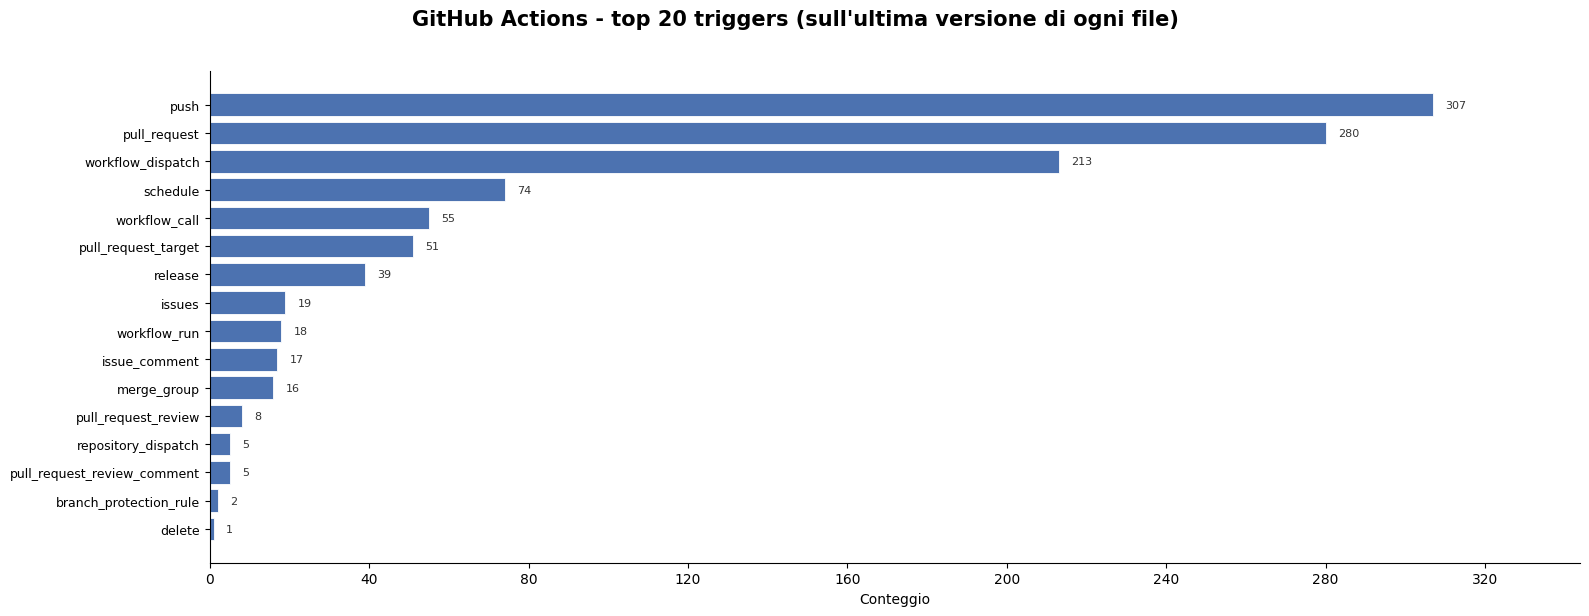

In [5]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

TOP_N = 20

top_total = total_trigger_counter_unique.most_common(TOP_N)

labels_total, values_total = zip(*top_total)

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle(f"GitHub Actions - top {TOP_N} triggers (sull'ultima versione di ogni file)", fontsize=15, fontweight="bold", y=1.02)

def bar_chart(ax, labels, values, color):
    bars = ax.barh(labels[::-1], values[::-1], color=color, edgecolor="white", linewidth=0.6)
    ax.set_xlabel("Conteggio", fontsize=10)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)
    for bar, val in zip(bars, values[::-1]):
        ax.text(
            bar.get_width() + max(values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            str(val),
            va="center", ha="left", fontsize=8, color="#333"
        )
    ax.set_xlim(0, max(values) * 1.12)

bar_chart(
    ax, labels_total, values_total,
    "#4C72B0"
)

plt.tight_layout()
# plt.savefig("triggers_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**possiamo dedurre che:** per più del 50% del totale, se un workflow viene triggerato è perchè è stata rilevata una azione di push o pull request.

una fetta importante è occupata da workflow_dispatch, che occupa il 20% del totale. Workflow dispatch indica che l'azione del workflow è stata avviata a mano.

al quarto posto con circa il 9% abbiamo schedule, il che indica che alcune repositories hanno delle azioni ricorrenti.

successivamente andremo ad analizzare quali sono le azioni più effettuate durante ciascuno dei trigger, in modo da capire meglio cosa viene effettuato e quando.

In [13]:
from collections import Counter, defaultdict
from pathlib import Path
import yaml


def extract_job_keywords(workflow_dict):
    """Estrae le chiavi top-level della sezione jobs (es. tests, build, deploy)."""
    if not isinstance(workflow_dict, dict):
        return []

    jobs_section = workflow_dict.get("jobs")
    if isinstance(jobs_section, dict):
        return [str(k).strip() for k in jobs_section.keys() if str(k).strip()]

    return []


# trigger -> {total: int, jobs_counter: Counter}
trigger_stats = defaultdict(lambda: {"total": 0, "jobs_counter": Counter()})

for repo in repo_summary["repository"].unique():
    files = repo_summary.loc[repo_summary["repository"] == repo, "files"].values[0]

    for file in files:
        path = Path(BASE_GIGAWORK_PATH) / repo / file

        try:
            with open(path, "r", encoding="utf-8") as f:
                data = yaml.safe_load(f)
        except Exception:
            continue

        if not isinstance(data, dict):
            continue

        triggers = extract_triggers(get_on_section(data))
        if not triggers:
            continue

        job_keywords = extract_job_keywords(data)

        # Conta una volta per trigger per file workflow
        for trigger in set(triggers):
            trigger_stats[trigger]["total"] += 1
            trigger_stats[trigger]["jobs_counter"].update(job_keywords)


result = {
    trigger: {
        "total": values["total"],
        "most_associated_keywords": dict(values["jobs_counter"].most_common(20)),
    }
    for trigger, values in sorted(
        trigger_stats.items(),
        key=lambda item: item[1]["total"],
        reverse=True,
    )
}

# print(result)
# import json
# print(json.dumps(result,sort_keys=True,indent=2))


##### analizziamo ciò che succede durante uno schedule

In [33]:
import json
print(json.dumps(result['schedule']['most_associated_keywords'], sort_keys=True, indent=2))

{
  "agent-protocol-test": 1,
  "analysis": 2,
  "analyze": 8,
  "benchmark": 1,
  "build": 7,
  "build-docker": 1,
  "check_version": 2,
  "close-issues": 3,
  "convert_stale_prs": 1,
  "cron-scheduleEmailReminders": 2,
  "delete-cache": 1,
  "deploy": 4,
  "lint": 2,
  "mark-stale-issues": 1,
  "markdown-link-check": 2,
  "run-cn-task": 2,
  "run-integration-tests": 1,
  "serve-agent-protocol": 1,
  "stale": 7,
  "test-on-macos": 1
}


In [32]:
# raggruppamento in categorie dei job, per capire meglio cosa viene fatto nei workflow associati a schedule

import re
from collections import defaultdict

def classify_job_name(job_name: str, extended_vocab: bool = False) -> str:
    s = job_name.strip().lower().replace("_", "-")
    tokens = set(re.findall(r"[a-z0-9]+", s))

    def has_any(*words):
        return any(w in tokens for w in words)

    if has_any("deploy", "release", "publish", "ship", "rollout"):
        return "cd_release"
    if has_any("test", "tests", "integration", "e2e", "unit", "smoke"):
        return "ci_testing"
    if has_any("build", "compile", "package", "docker", "image"):
        return "ci_build"
    if has_any("lint", "format", "fmt", "style", "typecheck", "scan", "security", "sast"):
        return "quality_security"
    if has_any("stale", "cleanup", "clean", "cache", "close", "triage", "housekeeping"):
        return "repo_maintenance"
    if has_any("analyze", "analysis", "benchmark", "metrics", "report", "profile"):
        return "analysis_monitoring"
    if has_any("cron", "schedule", "sync", "backup", "rotate", "refresh"):
        return "scheduled_ops"

    if not extended_vocab:
        return "other"

    if has_any(
        "claude", "autopr", "auto", "fix", "run", "agent", "copilot",
        "llm", "gpt", "ai", "dogfood", "devin", "prompt", "assistant"
    ):
        return "ai_native"

    if has_any("pytest", "unittest", "unittests", "integrationtest", "integrationtests"):
        return "ci_testing"

    if has_any(
        "check", "checks", "pre", "commit", "codespell", "spell",
        "size", "conflict", "conflicts", "mypy", "pyright",
        "type", "format", "verify", "version", "changed", "files"
    ):
        return "quality_security"

    if has_any("prerelease", "artifact", "publish", "release"):
        return "cd_release"

    if has_any("migrate", "migration", "cleanup", "housekeeping"):
        return "repo_maintenance"

    if has_any("notify", "notification", "slack", "teams", "mail", "email", "webhook"):
        return "scheduled_ops"

    if has_any("main", "changes"):
        return "analysis_monitoring"

    return "other"


def group_jobs_generic(job_counter: dict, extended_vocab: bool = False) -> dict:
    grouped = defaultdict(lambda: {"total": 0, "items": {}})
    for job, count in sorted(job_counter.items()):
        g = classify_job_name(job, extended_vocab)
        grouped[g]["total"] += int(count)
        grouped[g]["items"][job] = int(count)
    return dict(sorted(grouped.items(), key=lambda x: (-x[1]["total"], x[0])))

generic_grouped = group_jobs_generic(result["schedule"]["most_associated_keywords"])
print(generic_grouped)

{'repo_maintenance': {'total': 13, 'items': {'close-issues': 3, 'convert_stale_prs': 1, 'delete-cache': 1, 'mark-stale-issues': 1, 'stale': 7}}, 'analysis_monitoring': {'total': 11, 'items': {'analysis': 2, 'analyze': 8, 'benchmark': 1}}, 'ci_build': {'total': 8, 'items': {'build': 7, 'build-docker': 1}}, 'other': {'total': 7, 'items': {'check_version': 2, 'markdown-link-check': 2, 'run-cn-task': 2, 'serve-agent-protocol': 1}}, 'cd_release': {'total': 4, 'items': {'deploy': 4}}, 'ci_testing': {'total': 3, 'items': {'agent-protocol-test': 1, 'run-integration-tests': 1, 'test-on-macos': 1}}, 'quality_security': {'total': 2, 'items': {'lint': 2}}, 'scheduled_ops': {'total': 2, 'items': {'cron-scheduleEmailReminders': 2}}}


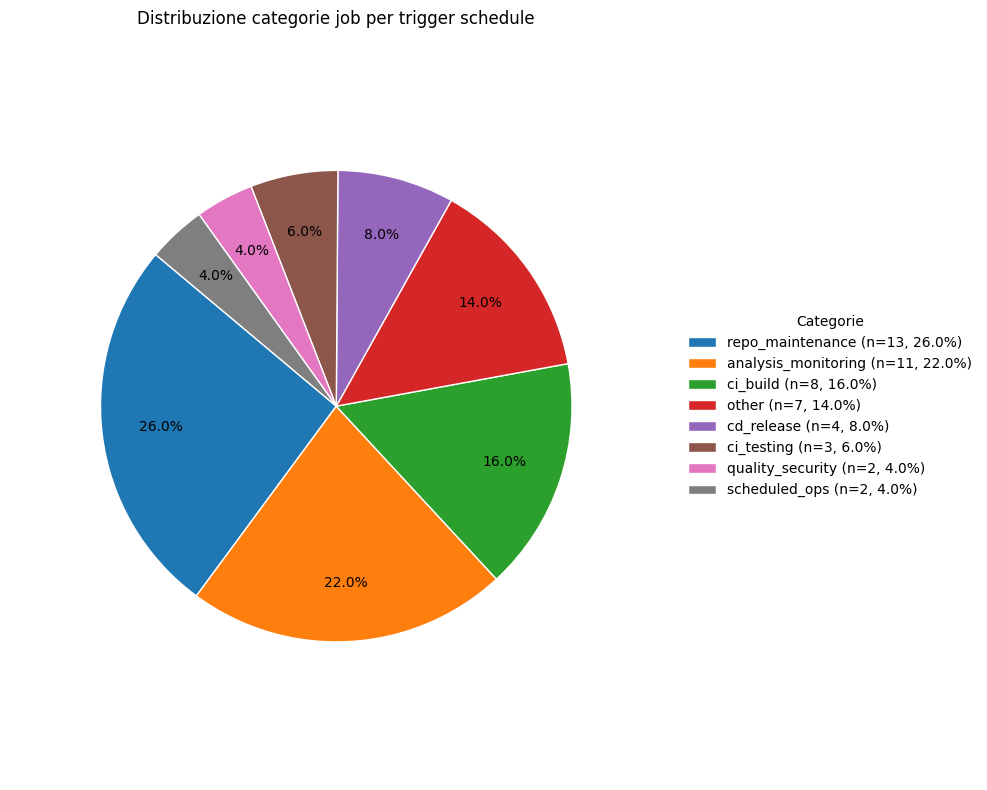

In [34]:
import matplotlib.pyplot as plt

def plot_job_category_pie(grouped_data, title="Distribuzione categorie job", legend_title="Categorie", figsize=(10, 8), startangle=140):
    labels = list(grouped_data.keys())
    values = [v["total"] for v in grouped_data.values()]
    total = sum(values)

    fig, ax = plt.subplots(figsize=figsize)

    wedges, _, _ = ax.pie(
        values,
        startangle=startangle,
        autopct=lambda p: f"{p:.1f}%",
        pctdistance=0.75,
        wedgeprops={"edgecolor": "white", "linewidth": 1}
    )

    legend_labels = [f"{lbl} (n={val}, {val/total*100:.1f}%)" for lbl, val in zip(labels, values)]
    ax.legend(
        wedges,
        legend_labels,
        title=legend_title,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    ax.set_title(title)
    ax.axis("equal")
    plt.tight_layout()
    plt.show()

plot_job_category_pie(
    generic_grouped,
    title="Distribuzione categorie job per trigger schedule"
)

#### da qui possiamo osservare che per il 22% le azioni collegate ad uno schedule sono della categoria analisi e monitoring (servono a misurare e osservare il progetto nel tempo, ad esempio analisi periodiche, benchmark e generazione di metriche/report), mentre per il 26% si tratta di manutezione della repository (per mantenere la repository ordinata). Per il 16% invece vengono eseguite operazioni di build periodiche

#### analizziamo cosa succede nei push

{'ci_build': {'total': 66, 'items': {'build': 66}}, 'cd_release': {'total': 53, 'items': {'create-release': 5, 'deploy': 20, 'publish': 9, 'publish_docker_to_ecr': 3, 'release': 16}}, 'ci_testing': {'total': 42, 'items': {'pytest': 4, 'test': 38}}, 'quality_security': {'total': 33, 'items': {'check': 3, 'codespell': 2, 'conflicts': 3, 'lint': 15, 'pre-commit': 4, 'require-all-checks-to-pass': 3, 'size': 3}}, 'analysis_monitoring': {'total': 11, 'items': {'analyze': 11}}, 'other': {'total': 6, 'items': {'docs': 3, 'setup': 3}}, 'repo_maintenance': {'total': 4, 'items': {'migrate': 4}}, 'scheduled_ops': {'total': 3, 'items': {'notify': 3}}}


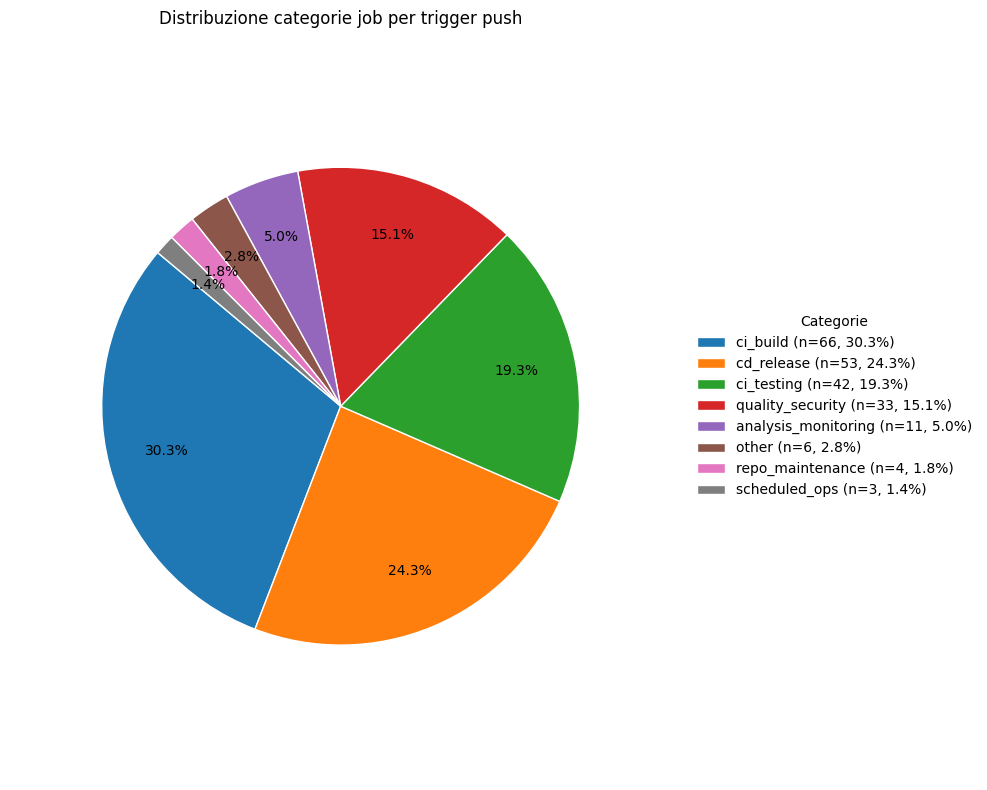

In [35]:
push_grouped = group_jobs_generic(result["push"]["most_associated_keywords"], extended_vocab=True)
print(push_grouped)

plot_job_category_pie(
    push_grouped,
    title="Distribuzione categorie job per trigger push"
)

#### possiamo notare che per quanto riguarda le azioni collegate al push in più del 75% delle volte sono correlate al build, release o testing, quindi sostanzialmente collegate a CI/CD

{'ci_testing': {'total': 45, 'items': {'pytest': 5, 'test': 37, 'unit-tests': 3}}, 'quality_security': {'total': 45, 'items': {'changed-files': 4, 'format': 5, 'lint': 17, 'mypy': 3, 'pre-commit': 4, 'pyright': 3, 'require-all-checks-to-pass': 3, 'type-check': 3, 'verify-version': 3}}, 'ci_build': {'total': 37, 'items': {'build': 37}}, 'analysis_monitoring': {'total': 17, 'items': {'analyze': 10, 'changes': 3, 'main': 4}}, 'cd_release': {'total': 6, 'items': {'block-prerelease': 3, 'deploy': 3}}, 'ai_native': {'total': 3, 'items': {'claude-review': 3}}, 'other': {'total': 3, 'items': {'setup': 3}}}


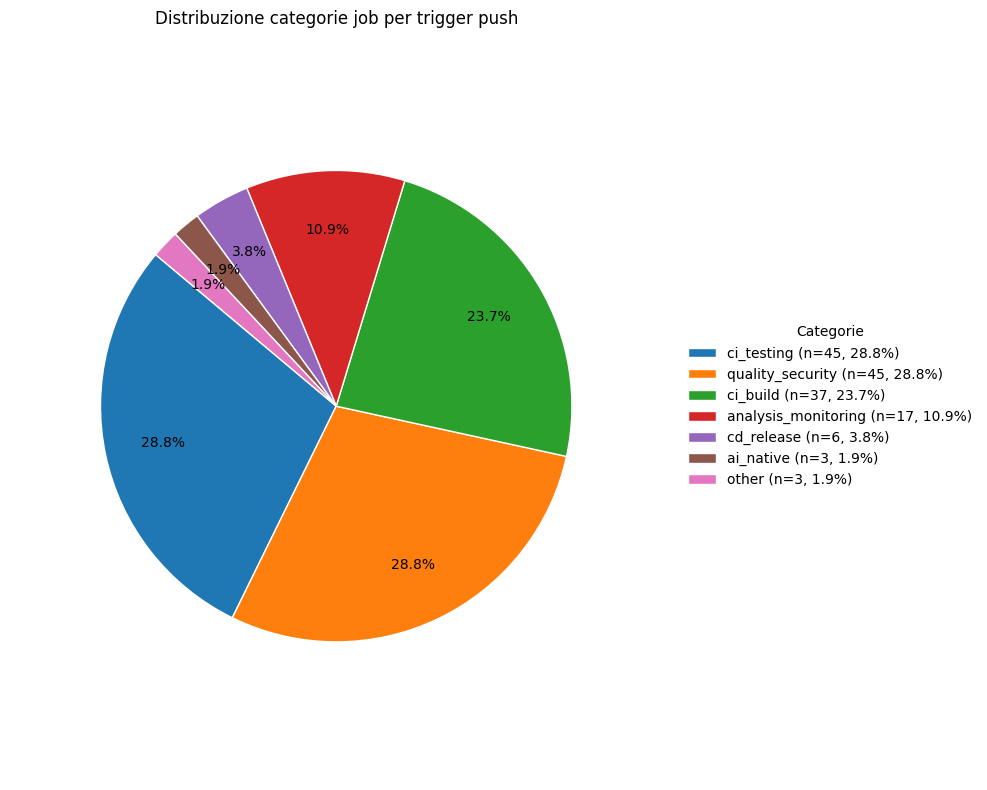

In [36]:
push_grouped = group_jobs_generic(result["pull_request"]["most_associated_keywords"], extended_vocab=True)
print(push_grouped)

plot_job_category_pie(
    push_grouped,
    title="Distribuzione categorie job per trigger push"
)

#### per quanto riguarda le pull requests, vi sono associate maggiormente operazioni di testing e build, ma spicca la categoria quality and security al 28%. inoltre notiamo un'inizio di adozione di job collegati all'IA, ieg: claude-review